# Learning rate and regularization

Map the stability and performance of gradient-descent self-training over step size and ridge regularization.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

import numpy as np
import torch
from matplotlib import pyplot as plt
from scipy.special import logit

torch.set_default_dtype(torch.float64)
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks.experiment_helpers import (
    as_numpy,
    finite_state_observables,
    finite_update_observables,
    make_algorithm_config,
    trajectory_diagnostics,
    plot_macroscopic_evolution,
    make_parameter_base_sampler,
    mean_and_std,
    run_experiment,
    run_oracle_selected_label_counterfactual,
    state_evolution_state_observables,
    state_evolution_update_observables,
)
from src.asymptotics import MacroscopicStateEvolution
from src.config import DataConfig
from src.environment import FourCellSampleTypeLaw, state_evolution_sample_base_sampler


## Unbalenced Priors

In [3]:
SEED = 9100
T, D, DELTA = 70, 700, 2.0
K_W, K_G = 3_500, 4_200
ETAS = np.array([0.025, 0.05, 0.1, 0.2, 0.35])
LAMBDAS = np.array([0.0, 0.03, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0])

final_error = np.full((len(LAMBDAS), len(ETAS)), np.nan)
runs = {}
for i, penalty in enumerate(LAMBDAS):
    for j, eta in enumerate(ETAS):
        cfg = make_algorithm_config(T=T, eta=float(eta), penalty=float(penalty), pi=5.0, kappa=logit(0.8))
        run = run_experiment(
            name=rf"eta={eta}, lambda={penalty}", d=D, delta=DELTA, n_test=1_500, label_prior=0.2, rho=0.1, sigma=1.0, signal_std=1.0,
            algo_cfg=cfg, seed=SEED, K_w=K_W, K_g=K_G,
        )
        runs[(float(eta), float(penalty))] = run
        final_error[i, j] = state_evolution_state_observables(run)["error"][-1]

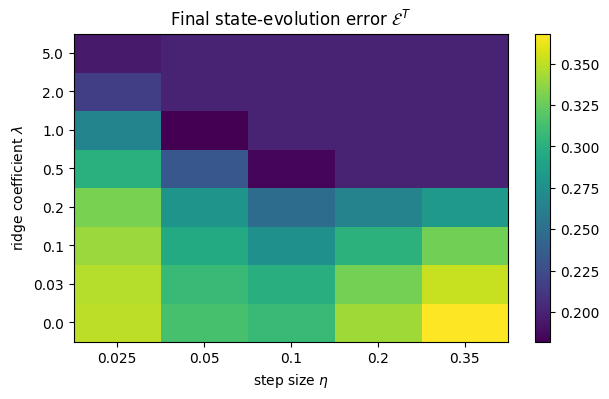

In [4]:
plt.figure(figsize=(7, 4))
image = plt.imshow(final_error, origin="lower", aspect="auto", cmap="viridis")
plt.xticks(np.arange(len(ETAS)), ETAS); plt.yticks(np.arange(len(LAMBDAS)), LAMBDAS)
plt.xlabel(r"step size $\eta$"); plt.ylabel(r"ridge coefficient $\lambda$"); plt.title(r"Final state-evolution error $\mathcal{E}^T$")
plt.colorbar(image); plt.show()

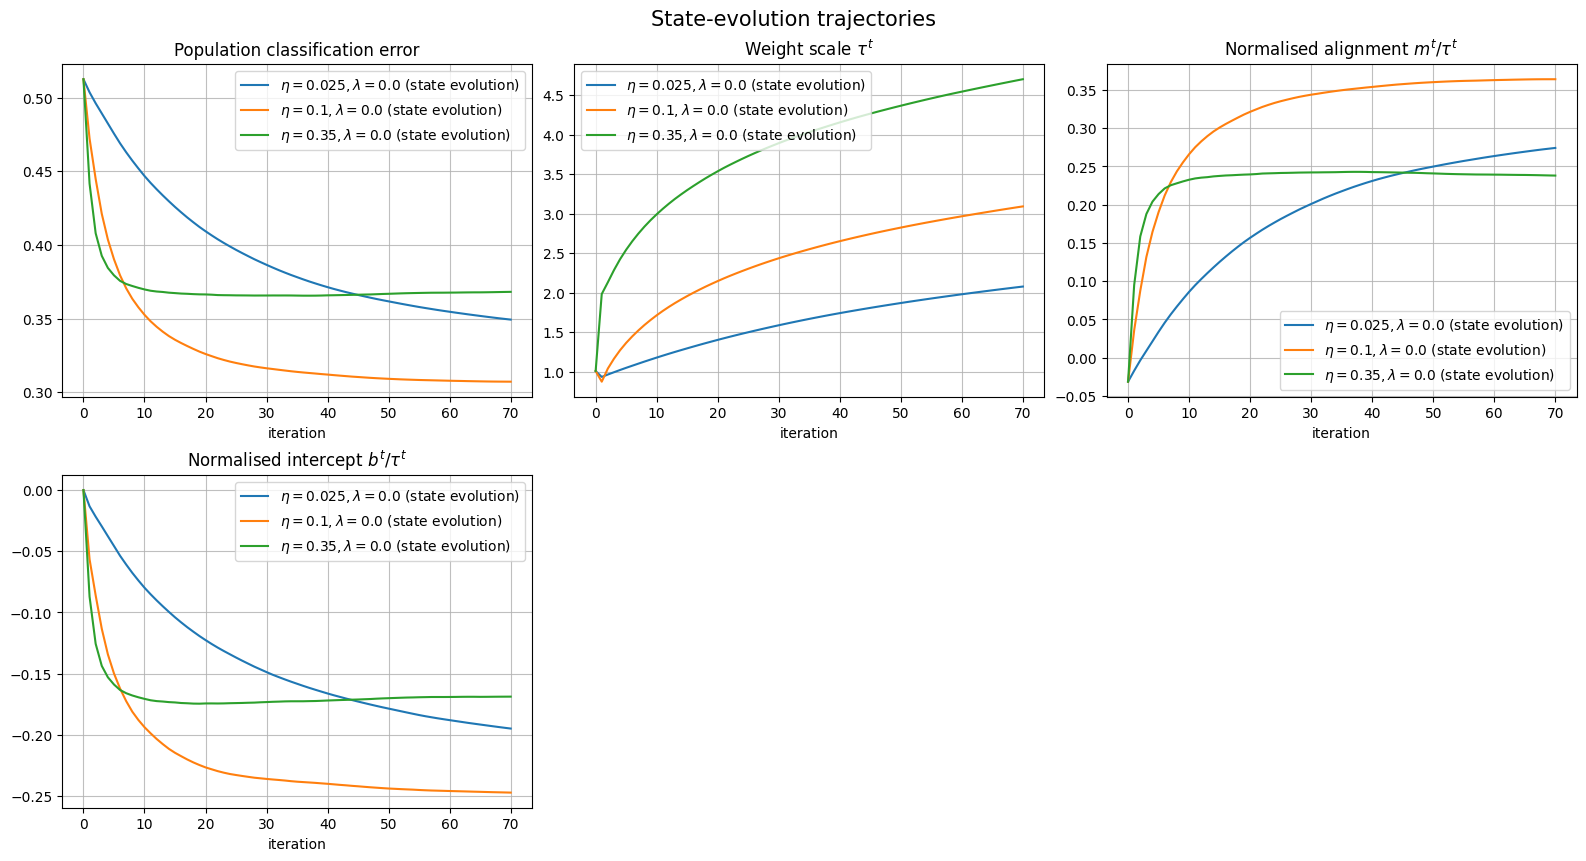

(<Figure size 1575x850 with 4 Axes>,
 array([[<Axes: title={'center': 'Population classification error'}, xlabel='iteration'>,
         <Axes: title={'center': 'Weight scale $\\tau^t$'}, xlabel='iteration'>,
         <Axes: title={'center': 'Normalised alignment $m^t/\\tau^t$'}, xlabel='iteration'>],
        [<Axes: title={'center': 'Normalised intercept $b^t/\\tau^t$'}, xlabel='iteration'>,
         <Axes: >, <Axes: >]], dtype=object))

In [5]:
representative = ((0.025, 0.0), (0.1, 0.0), (0.35, 0.0))
representative_runs = {
    rf"$\eta={eta},\lambda={penalty}$": runs[(eta, penalty)]
    for eta, penalty in representative
}
plot_macroscopic_evolution(
    representative_runs,
    quantities=("error", "tau", "normalized_alignment", "normalized_bias"),
    sources=("state_evolution",),
    include_bayes=False,
    title="State-evolution trajectories",
)

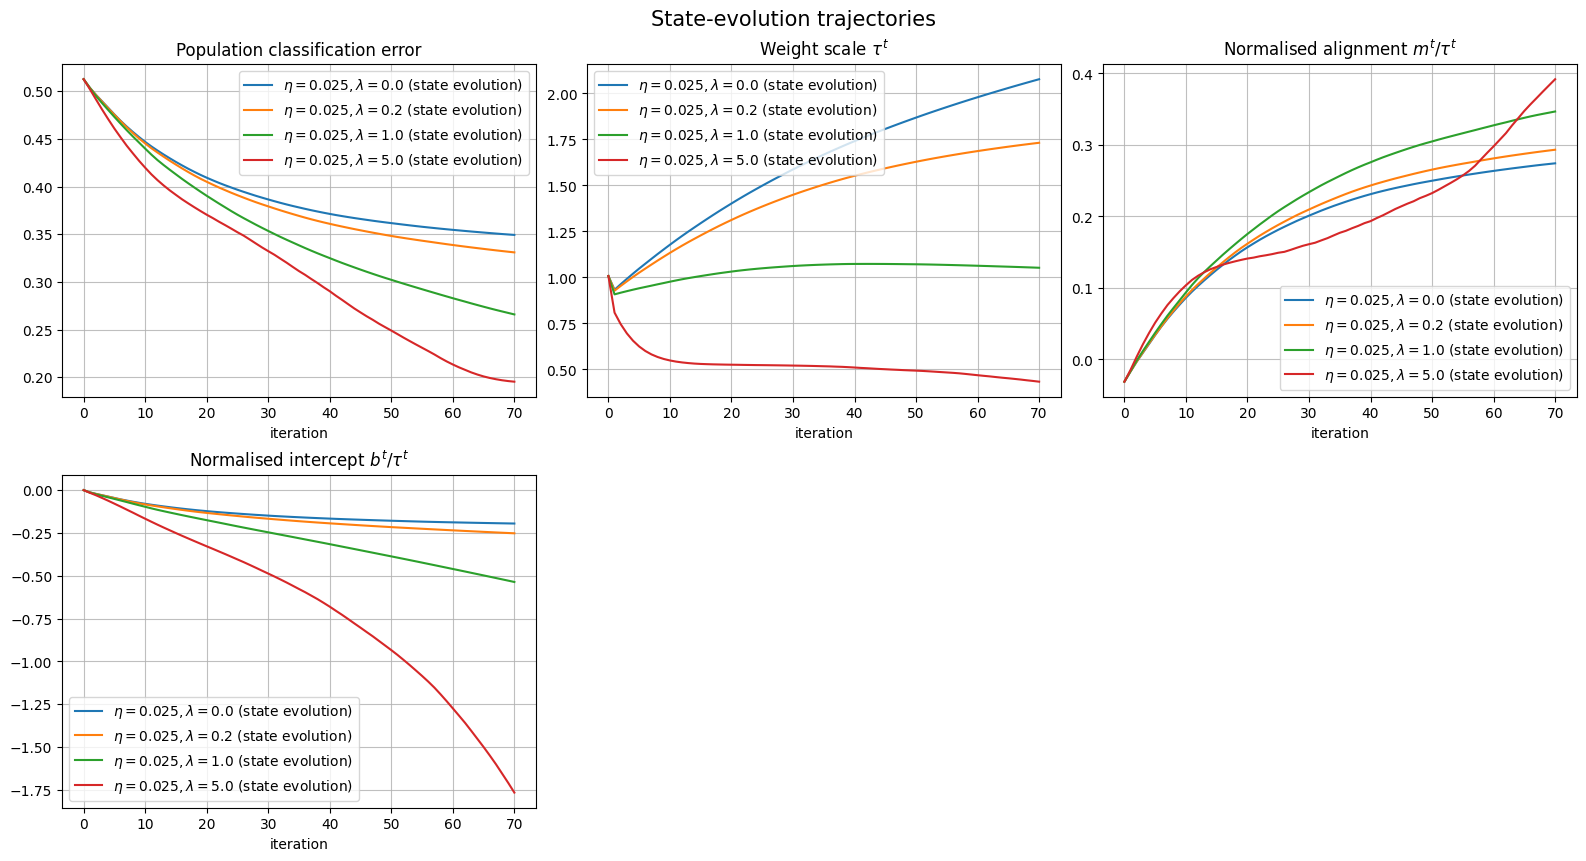

(<Figure size 1575x850 with 4 Axes>,
 array([[<Axes: title={'center': 'Population classification error'}, xlabel='iteration'>,
         <Axes: title={'center': 'Weight scale $\\tau^t$'}, xlabel='iteration'>,
         <Axes: title={'center': 'Normalised alignment $m^t/\\tau^t$'}, xlabel='iteration'>],
        [<Axes: title={'center': 'Normalised intercept $b^t/\\tau^t$'}, xlabel='iteration'>,
         <Axes: >, <Axes: >]], dtype=object))

In [6]:
representative = ((0.025, 0.0), (0.025, 0.2), (0.025, 1.0), (0.025, 5.0))
representative_runs = {
    rf"$\eta={eta},\lambda={penalty}$": runs[(eta, penalty)]
    for eta, penalty in representative
}
plot_macroscopic_evolution(
    representative_runs,
    quantities=("error", "tau", "normalized_alignment", "normalized_bias"),
    sources=("state_evolution",),
    include_bayes=False,
    title="State-evolution trajectories",
)

## Balenced Priors

In [7]:
SEED = 9100
T, D, DELTA = 70, 700, 2.0
K_W, K_G = 3_500, 4_200
ETAS = np.array([0.025, 0.05, 0.1, 0.2, 0.35])
LAMBDAS = np.array([0.0, 1.0, 2.0, 5.0, 10.0, 20.0])

final_error = np.full((len(LAMBDAS), len(ETAS)), np.nan)
runs = {}
for i, penalty in enumerate(LAMBDAS):
    for j, eta in enumerate(ETAS):
        cfg = make_algorithm_config(T=T, eta=float(eta), penalty=float(penalty), pi=5.0, kappa=logit(0.8))
        run = run_experiment(
            name=rf"eta={eta}, lambda={penalty}", d=D, delta=DELTA, n_test=1_500, label_prior=0.5, rho=0.1, sigma=1.0, signal_std=1.0,
            algo_cfg=cfg, seed=SEED, K_w=K_W, K_g=K_G,
        )
        runs[(float(eta), float(penalty))] = run
        final_error[i, j] = state_evolution_state_observables(run)["error"][-1]

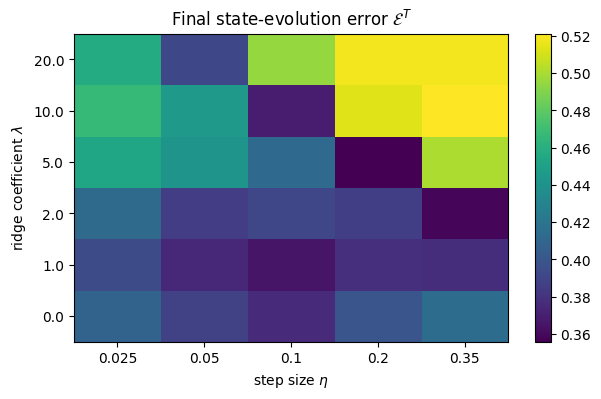

In [8]:
plt.figure(figsize=(7, 4))
image = plt.imshow(final_error, origin="lower", aspect="auto", cmap="viridis")
plt.xticks(np.arange(len(ETAS)), ETAS); plt.yticks(np.arange(len(LAMBDAS)), LAMBDAS)
plt.xlabel(r"step size $\eta$"); plt.ylabel(r"ridge coefficient $\lambda$"); plt.title(r"Final state-evolution error $\mathcal{E}^T$")
plt.colorbar(image); plt.show()

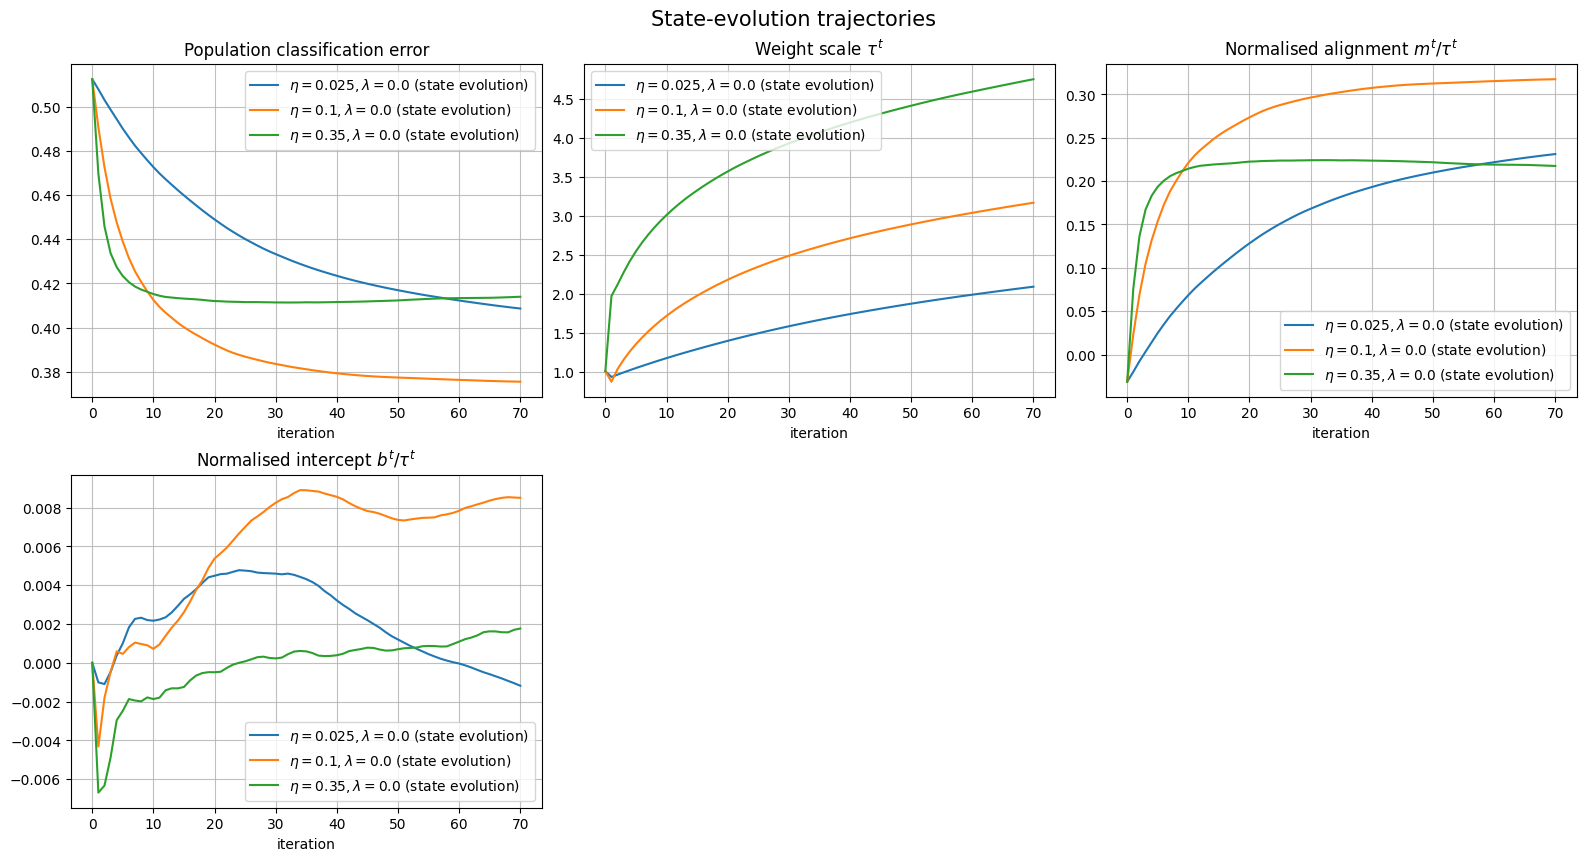

(<Figure size 1575x850 with 4 Axes>,
 array([[<Axes: title={'center': 'Population classification error'}, xlabel='iteration'>,
         <Axes: title={'center': 'Weight scale $\\tau^t$'}, xlabel='iteration'>,
         <Axes: title={'center': 'Normalised alignment $m^t/\\tau^t$'}, xlabel='iteration'>],
        [<Axes: title={'center': 'Normalised intercept $b^t/\\tau^t$'}, xlabel='iteration'>,
         <Axes: >, <Axes: >]], dtype=object))

In [9]:
representative = ((0.025, 0.0), (0.1, 0.0), (0.35, 0.0))
representative_runs = {
    rf"$\eta={eta},\lambda={penalty}$": runs[(eta, penalty)]
    for eta, penalty in representative
}
plot_macroscopic_evolution(
    representative_runs,
    quantities=("error", "tau", "normalized_alignment", "normalized_bias"),
    sources=("state_evolution",),
    include_bayes=False,
    title="State-evolution trajectories",
)

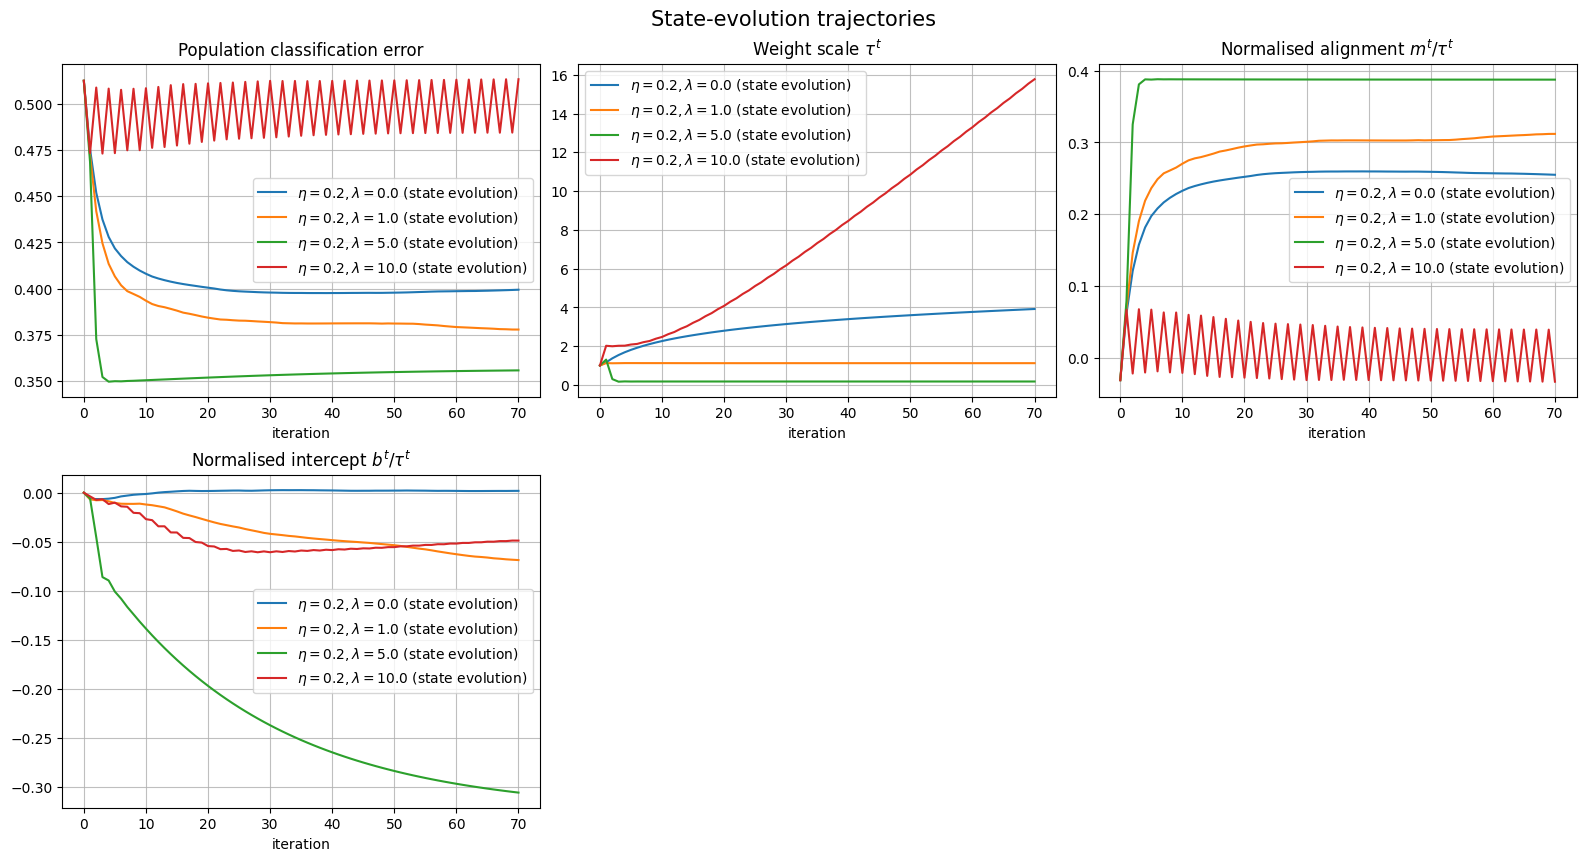

(<Figure size 1575x850 with 4 Axes>,
 array([[<Axes: title={'center': 'Population classification error'}, xlabel='iteration'>,
         <Axes: title={'center': 'Weight scale $\\tau^t$'}, xlabel='iteration'>,
         <Axes: title={'center': 'Normalised alignment $m^t/\\tau^t$'}, xlabel='iteration'>],
        [<Axes: title={'center': 'Normalised intercept $b^t/\\tau^t$'}, xlabel='iteration'>,
         <Axes: >, <Axes: >]], dtype=object))

In [10]:
representative = ((0.2, 0.0), (0.2, 1.0), (0.2, 5.0), (0.2, 10.0))
representative_runs = {
    rf"$\eta={eta},\lambda={penalty}$": runs[(eta, penalty)]
    for eta, penalty in representative
}
plot_macroscopic_evolution(
    representative_runs,
    quantities=("error", "tau", "normalized_alignment", "normalized_bias"),
    sources=("state_evolution",),
    include_bayes=False,
    title="State-evolution trajectories",
)

## Stability diagnostics

Final error is augmented by best-time error, late-time oscillation amplitude, terminal scale, and intercept-dominance collapse.  

In [11]:
diagnostic_table = {
    (eta, penalty): trajectory_diagnostics(run, convergence_window=10)
    for (eta, penalty), run in runs.items()
}
for key, values in diagnostic_table.items():
    print(key, values)

RUN_REPEATED_STABILITY_CELLS = True
if RUN_REPEATED_STABILITY_CELLS:
    representative_cells = ((0.025, 0.0), (0.2, 0.0), (0.35, 0.0))
    for eta, penalty in representative_cells:
        repeated = [run_experiment(name=rf"eta={eta}, lambda={penalty}, seed={seed}", d=D, delta=DELTA, n_test=1_500, label_prior=0.5, rho=0.1, sigma=1.0, signal_std=1.0, algo_cfg=make_algorithm_config(T=T, eta=eta, penalty=penalty, pi=5.0, kappa=logit(0.8)), seed=SEED + seed, K_w=K_W, K_g=K_G) for seed in range(5)]
        terminal = np.array([trajectory_diagnostics(run)["terminal_error"] for run in repeated])
        print((eta, penalty), {"terminal_error_mean": terminal.mean(), "terminal_error_se": terminal.std(ddof=1) / np.sqrt(terminal.size)})

(0.025, 0.0) {'terminal_error': 0.4085952833963593, 'minimum_error': 0.4085952833963593, 'best_iteration': 70, 'late_error_range': 0.0032332426915079315, 'terminal_normalized_bias': -0.0011825620941508924, 'terminal_normalized_alignment': 0.2311600805900689, 'terminal_weight_scale': 2.0905164223962385, 'collapsed': False}
(0.05, 0.0) {'terminal_error': 0.3881889054870223, 'minimum_error': 0.3881889054870223, 'best_iteration': 70, 'late_error_range': 0.002149168328124451, 'terminal_normalized_bias': 0.008332936250061705, 'terminal_normalized_alignment': 0.2840523619260776, 'terminal_weight_scale': 2.5904240923179183, 'collapsed': False}
(0.1, 0.0) {'terminal_error': 0.37545639206462555, 'minimum_error': 0.37545639206462555, 'best_iteration': 70, 'late_error_range': 0.0007257766380051045, 'terminal_normalized_bias': 0.00850028084751211, 'terminal_normalized_alignment': 0.31744748206136014, 'terminal_weight_scale': 3.1662786617140863, 'collapsed': False}
(0.2, 0.0) {'terminal_error': 0.39